In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import joblib

# 1. Load dataset

In [35]:
df = pd.read_csv("loan_approval.csv")

In [36]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [37]:
df = df.drop("Applicant_ID", axis=1)

In [38]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [39]:
df.isnull().sum()

,0
Applicant_Income,50
Coapplicant_Income,50
Employment_Status,50
Age,50
Marital_Status,50
Dependents,50
Credit_Score,50
Existing_Loans,50
DTI_Ratio,50
Savings,50


In [7]:
print(df.describe())

       Applicant_Income  Coapplicant_Income         Age  Dependents  \
count        950.000000          950.000000  950.000000  950.000000   
mean       10852.571579         5082.455789   39.971579    1.474737   
std         5061.632859         2943.161570   11.139797    1.105067   
min         2009.000000            1.000000   21.000000    0.000000   
25%         6730.750000         2472.750000   30.250000    1.000000   
50%        10548.000000         5205.500000   40.000000    1.000000   
75%        15190.000000         7620.750000   49.000000    2.000000   
max        19988.000000         9996.000000   59.000000    3.000000   

       Credit_Score  Existing_Loans   DTI_Ratio       Savings  \
count    950.000000      950.000000  950.000000    950.000000   
mean     676.033684        1.950526    0.347263   9940.452632   
std       71.346015        1.406246    0.144341   5860.736885   
min      550.000000        0.000000    0.100000     65.000000   
25%      616.250000        1.000000

In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Marital_Status                   1000 non-null   int64  
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Gender               

# 2. Handle missing values

In [40]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [41]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [42]:
numerical_cols

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [43]:
from sklearn.impute import SimpleImputer
# For numerical: fill missing with median
num_imputer = SimpleImputer(strategy="median")
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [44]:
# For categorical: fill missing with most frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

#3. Exploratory Data Analysis

In [47]:
print(df['Loan_Approved'].value_counts())

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


In [51]:
import plotly.express as px

# Get counts
loan_status_count = df['Loan_Approved'].value_counts().reset_index()
loan_status_count.columns = ['Loan_Approved', 'count']

# Plot pie chart
fig_loan_status = px.pie(loan_status_count,
                         names='Loan_Approved',
                         values='count',
                         title='Loan Approval Status',
                         hole=0.3)  # optional: donut chart
fig_loan_status.show()

In [52]:
gender_count = df['Gender'].value_counts()
fig_gender = px.bar(gender_count,
                    x=gender_count.index,
                    y=gender_count.values,
                    title='Gender Distribution')
fig_gender.show()

In [53]:
married_count = df['Marital_Status'].value_counts()
fig_married = px.bar(married_count,
                     x=married_count.index,
                     y=married_count.values,
                     title='Marital Status Distribution')
fig_married.show()

In [56]:
education_count = df['Education_Level'].value_counts()
fig_education = px.bar(education_count,
                       x=education_count.index,
                       y=education_count.values,
                       title='Education Distribution')
fig_education.show()

In [57]:
self_employed_count = df['Employer_Category'].value_counts()
fig_self_employed = px.bar(self_employed_count,
                           x=self_employed_count.index,
                           y=self_employed_count.values,
                           title='Self-Employment Distribution')
fig_self_employed.show()

In [58]:
fig_applicant_income = px.histogram(df, x='Applicant_Income',
                                    title='Applicant Income Distribution')
fig_applicant_income.show()

In [60]:
fig_applicant_income = px.histogram(df, x='Coapplicant_Income',
                                    title='Applicant Income Distribution')
fig_applicant_income.show()

In [62]:
fig_income = px.box(df, x='Loan_Approved',
                    y='Applicant_Income',
                    color="Loan_Approved",
                    title='Loan_Status vs ApplicantIncome')
fig_income.show()

In [63]:
fig_income = px.box(df, x='Loan_Approved',
                    y='Coapplicant_Income',
                    color="Loan_Approved",
                    title='Loan_Status vs CoapplicantIncome')
fig_income.show()

In [64]:
fig_loan_amount = px.box(df, x='Loan_Approved',
                         y='Loan_Amount',
                         color="Loan_Approved",
                         title='Loan_Status vs LoanAmount')
fig_loan_amount.show()

In [68]:
fig_credit_history = px.histogram(df, x='Credit_Score', color='Loan_Approved',
                                  barmode='group',
                                  title='Loan_Status vs Credit_Score')
fig_credit_history.show()

In [67]:
fig_property_area = px.histogram(df, x='Property_Area', color='Loan_Approved',
                                 barmode='group',
                                title='Loan_Approved vs Property_Area')
fig_property_area.show()

# 4. Encode Categorical Variables

In [69]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
# Example: Label encode binary categorical variables
label_encoder = LabelEncoder()
for col in ["Marital_Status", "Gender", "Loan_Approved"]:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])

# 5.  One-hot encode multi-class categorical variables

In [70]:
df = pd.get_dummies(df, columns=[
    "Employment_Status",
    "Loan_Purpose",
    "Property_Area",
    "Education_Level",
    "Employer_Category"
], drop_first=True)

In [71]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,False,False,True,False,True,True,False,False,True,False
1,2860.0,2679.0,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,False,False,False,True,False,False,False,False,True,False
2,7390.0,2106.0,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,...,False,False,False,False,True,False,True,False,False,False
3,13964.0,8173.0,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,False,False,False,False,False,False,True,False,False,False
4,13284.0,4223.0,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,...,False,False,False,False,True,False,False,False,True,False


#6. Correlation Heatmap

Loan_Approved         1.000000
Credit_Score          0.451235
Applicant_Income      0.120177
Marital_Status        0.030182
Collateral_Value      0.021709
Coapplicant_Income    0.003957
Savings              -0.013462
Dependents           -0.018999
Age                  -0.022354
Existing_Loans       -0.035101
Gender               -0.054342
Loan_Term            -0.086644
Loan_Amount          -0.126608
DTI_Ratio            -0.444766
Name: Loan_Approved, dtype: float64


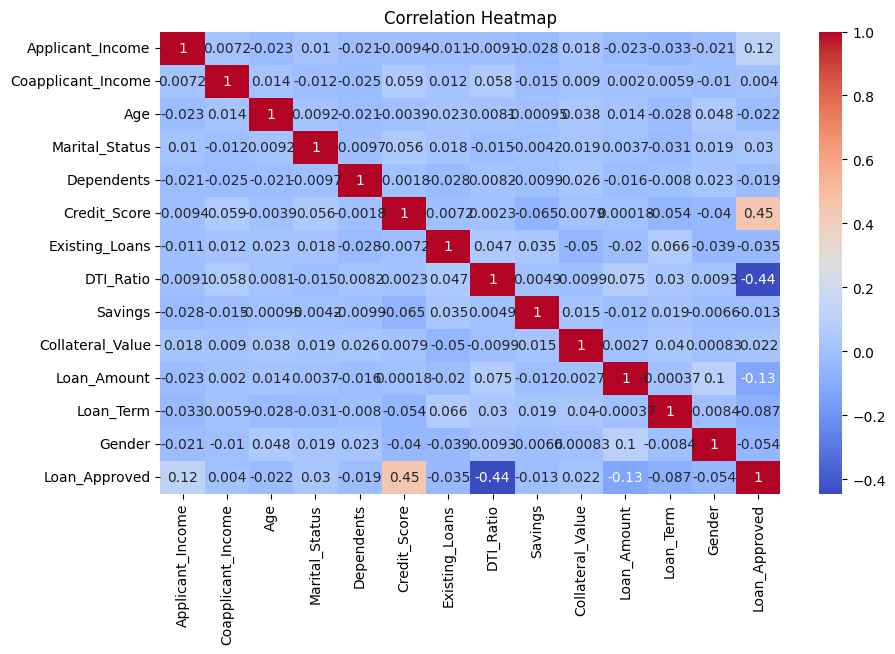

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()["Loan_Approved"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [79]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.410912,-1.290994,1.016124,0,-1.341680,-0.563016,1.494204,1.302077,1.657903,1.492563,...,False,False,True,False,True,True,False,False,True,False
1,-1.617690,-0.840389,0.555381,0,1.432296,-0.793218,0.034308,-0.333520,-1.288668,1.752590,...,False,False,False,True,False,False,False,False,True,False
2,-0.699071,-1.040231,-1.379744,1,0.507638,-0.030674,1.494204,-1.044649,0.684237,-1.278718,...,False,False,False,False,True,False,True,False,False,False
3,0.634041,1.075730,0.002488,0,0.507638,-1.397498,0.764256,-0.262407,-0.067338,-0.997082,...,False,False,False,False,False,False,True,False,False,False
4,0.496147,-0.301894,-0.826851,1,0.507638,0.645544,-0.695641,-0.404632,-0.096588,0.919488,...,False,False,False,False,True,False,False,False,True,False


In [81]:
# Split the dataset into features (X) and target (y)
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [82]:
X

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.410912,-1.290994,1.016124,0,-1.341680,-0.563016,1.494204,1.302077,1.657903,1.492563,...,False,False,True,False,True,True,False,False,True,False
1,-1.617690,-0.840389,0.555381,0,1.432296,-0.793218,0.034308,-0.333520,-1.288668,1.752590,...,False,False,False,True,False,False,False,False,True,False
2,-0.699071,-1.040231,-1.379744,1,0.507638,-0.030674,1.494204,-1.044649,0.684237,-1.278718,...,False,False,False,False,True,False,True,False,False,False
3,0.634041,1.075730,0.002488,0,0.507638,-1.397498,0.764256,-0.262407,-0.067338,-0.997082,...,False,False,False,False,False,False,True,False,False,False
4,0.496147,-0.301894,-0.826851,1,0.507638,0.645544,-0.695641,-0.404632,-0.096588,0.919488,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.058675,1.396246,1.661166,0,-1.341680,-1.714026,-1.425589,1.728755,-0.799996,1.344089,...,False,False,True,False,True,True,False,False,False,True
996,-1.532722,0.442023,1.661166,0,-0.417021,-0.433528,0.764256,-1.115762,-0.009976,-0.459211,...,False,False,False,False,True,False,True,False,False,False
997,0.883061,1.166409,0.739678,1,-0.417021,-0.145775,-0.695641,0.377610,-0.237585,1.184667,...,False,True,False,False,False,False,False,True,False,False
998,-0.355755,0.799159,0.923976,1,-0.417021,1.034009,0.764256,-0.262407,0.622408,-1.133821,...,False,False,True,False,True,False,False,False,True,False


In [83]:
y

,Loan_Approved
0,0
1,0
2,1
3,0
4,1
...,...
995,0
996,0
997,0
998,1


#7. Training Loan Approval Prediction Model

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (SVM & Logistic benefit from scaling)

In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#  Train Models

In [57]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

In [58]:
# Support Vector Machine
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

In [59]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)  # RF doesn’t need scaling
rf_pred = rf_model.predict(X_test)

#  Evaluate Models

In [63]:
models = {
    "Logistic Regression": (y_test, log_pred),
    "SVM": (y_test, svm_pred),
    "Random Forest": (y_test, rf_pred)
}

In [64]:
accuracy_scores = {}

In [65]:
for model_name, (y_true, y_pred) in models.items():
    acc = accuracy_score(y_true, y_pred)
    accuracy_scores[model_name] = acc
    print(f"\n=== {model_name} ===")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))


=== Logistic Regression ===
Accuracy: 0.805
Confusion Matrix:
 [[115  25]
 [ 14  46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.82      0.86       140
           1       0.65      0.77      0.70        60

    accuracy                           0.81       200
   macro avg       0.77      0.79      0.78       200
weighted avg       0.82      0.81      0.81       200


=== SVM ===
Accuracy: 0.815
Confusion Matrix:
 [[118  22]
 [ 15  45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86       140
           1       0.67      0.75      0.71        60

    accuracy                           0.81       200
   macro avg       0.78      0.80      0.79       200
weighted avg       0.82      0.81      0.82       200


=== Random Forest ===
Accuracy: 0.905
Confusion Matrix:
 [[125  15]
 [  4  56]]
Classification Report:
               precision    recall  

# Best Model Selection

In [66]:
best_model = max(accuracy_scores, key=accuracy_scores.get)
print("\n🔥 Best Model based on Test Accuracy:", best_model, "with accuracy:", accuracy_scores[best_model])


🔥 Best Model based on Test Accuracy: Random Forest with accuracy: 0.905


In [ ]:
import pickle

best_model = rf_model

# Save the trained model
with open("best_loan_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✅ Best model saved as best_loan_model.pkl")


✅ Best model saved as best_loan_model.pkl


In [67]:
# Feature importances
importances = rf_model.feature_importances_

In [68]:
importances_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

In [69]:
importances_df.head()

,Feature,Importance
7,DTI_Ratio,0.289768
5,Credit_Score,0.283275
0,Applicant_Income,0.080149
10,Loan_Amount,0.054538
9,Collateral_Value,0.042060


In [70]:
# Sort and get top 3
indices = np.argsort(importances)[::-1][:3]
top_features = [(importances_df['Feature'].iloc[i], importances_df['Importance'].iloc[i]) for i in indices]

print("\n🔥 Top 3 features influencing loan approval:")
for f, val in top_features:
    print(f"{f}: {val:.4f}")


🔥 Top 3 features influencing loan approval:
Savings: 0.0370
Coapplicant_Income: 0.0385
DTI_Ratio: 0.2898


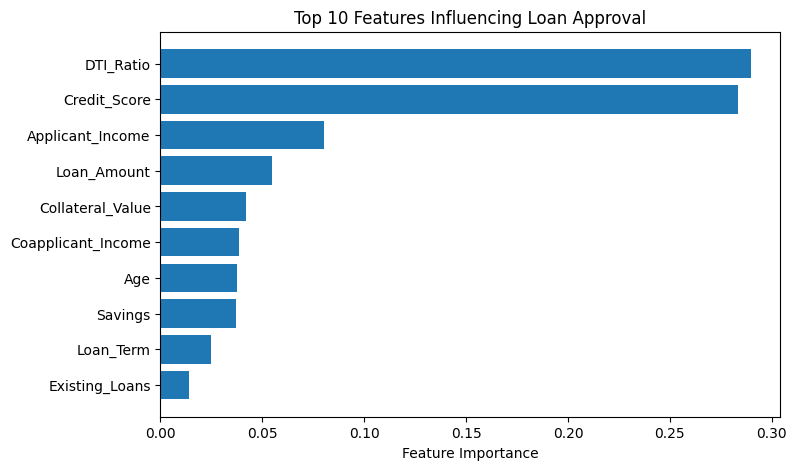

In [71]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Plot top N (say top 10)
plt.figure(figsize=(8,5))
plt.barh(importances_df["Feature"][:10][::-1], importances_df["Importance"][:10][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Features Influencing Loan Approval")
plt.show()


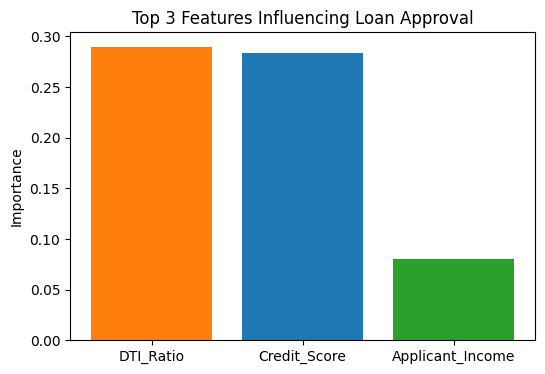

In [72]:
top3 = importances_df.head(3)

plt.figure(figsize=(6,4))
plt.bar(top3["Feature"], top3["Importance"], color=["#ff7f0e","#1f77b4","#2ca02c"])
plt.ylabel("Importance")
plt.title("Top 3 Features Influencing Loan Approval")
plt.show()
